In [1]:
import os
# 운영체제 관련 기능(환경변수 등)을 다루기 위한 표준 라이브러리
import pandas as pd
# 데이터프레임으로 데이터를 다루기 위한 라이브러리
import matplotlib.pyplot as plt
# 그래프를 그리기 위한 라이브러리
from dotenv import load_dotenv, find_dotenv
# .env 파일에서 환경변수를 불러오기 위한 함수들
from sqlalchemy import create_engine
# DB 연결 엔진을 생성하기 위한 함수


plt.rcParams['font.family'] = 'Malgun Gothic'
# 그래프에서 기본으로 쓸 폰트를 한글 지원 폰트(맑은 고딕)로 지정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
%matplotlib inline
# 그래프를 새 창이 아니라 셀 바로 아래에 표시하도록 설정

env_path = find_dotenv()
# 현재 프로젝트에서 .env 파일 경로를 자동으로 찾음
load_dotenv(env_path)
# 찾은 .env 파일의 내용을 환경변수로 불러옴
env_dir = os.path.dirname(env_path)
# .env 파일이 있는 폴더 경로 (인증서 파일 경로 계산에 사용)

HOST = os.environ["AIVEN_HOST"]
# DB 서버 주소
PORT = int(os.environ["AIVEN_PORT"])
# DB 포트 번호 (문자열을 정수로 변환)
USER = os.environ["AIVEN_USER"]
# DB 접속 계정
PASSWORD = os.environ["AIVEN_PASSWORD"]
# DB 접속 비밀번호
DB = os.environ["AIVEN_DB"]
# 접속할 데이터베이스 이름
CA_CERT_PATH = os.path.join(env_dir, os.environ["AIVEN_CA_CERT_PATH"])
# SSL 접속에 필요한 인증서 파일의 전체 경로

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}",
    connect_args={"ssl_ca": CA_CERT_PATH, "ssl_verify_cert": True}
)
# 위 접속 정보로 SSL 연결을 사용하는 DB 엔진 생성

# 연결 테스트
df = pd.read_sql("SELECT COUNT(*) AS cnt FROM tn_travel", engine)
# tn_travel 테이블의 전체 행 수를 조회해 연결이 되는지 테스트
print(df)
# 조회 결과 출력


    cnt
0  2880


In [2]:
purpose_query = """
WITH date_cnt AS (
    SELECT TRAVEL_START_YMD, COUNT(*) AS cnt
    FROM tn_travel
    GROUP BY TRAVEL_START_YMD
),
top3 AS (
    SELECT TRAVEL_START_YMD, cnt, 'TOP' AS grp
    FROM date_cnt
    ORDER BY cnt DESC, TRAVEL_START_YMD
    LIMIT 3
),
bottom_pool AS (
    SELECT TRAVEL_START_YMD, cnt
    FROM date_cnt
    WHERE cnt >= 10
    ORDER BY cnt ASC, TRAVEL_START_YMD
    LIMIT 18
),
bottom3 AS (
    SELECT TRAVEL_START_YMD, cnt, 'BOTTOM' AS grp
    FROM bottom_pool
    ORDER BY RAND(20260805)
    LIMIT 3
),
target_dates AS (
    SELECT * FROM top3
    UNION ALL
    SELECT * FROM bottom3
)
SELECT
    td.grp,
    td.TRAVEL_START_YMD,
    td.cnt AS date_total_travel_cnt,
    t.TRAVEL_ID,
    t.TRAVEL_PURPOSE
FROM target_dates td
JOIN tn_travel t ON t.TRAVEL_START_YMD = td.TRAVEL_START_YMD
ORDER BY td.grp, td.TRAVEL_START_YMD, t.TRAVEL_ID;
"""
# cnt 상위 3개 날짜(TOP)와, cnt>=10을 만족하는 날짜 중 하위 25%(18개) 풀에서
# 시드(20260805) 고정 랜덤으로 뽑은 3개 날짜(BOTTOM)를 grp로 구분해서
# 그 날짜에 속한 여행들의 TRAVEL_ID·TRAVEL_PURPOSE(다중선택, 세미콜론 구분)를 가져오는 쿼리

purpose_raw_df = pd.read_sql(purpose_query, engine)
# 쿼리를 실행해 TOP/BOTTOM 날짜별 여행 목적 원본 데이터를 데이터프레임으로 저장

print(f"조회된 여행 건수: {len(purpose_raw_df)}건 "
      f"(TOP {(purpose_raw_df['grp']=='TOP').sum()}건 / "
      f"BOTTOM {(purpose_raw_df['grp']=='BOTTOM').sum()}건)")
# TOP/BOTTOM 그룹별 표본 개수를 먼저 확인 (7원칙: 표본 개수 명시)

purpose_raw_df
# 원본 데이터 미리보기 (grp, 날짜, 날짜별 전체 여행건수, 여행ID, 목적 원본 문자열)

조회된 여행 건수: 505건 (TOP 468건 / BOTTOM 37건)


,grp,TRAVEL_START_YMD,date_total_travel_cnt,TRAVEL_ID,TRAVEL_PURPOSE
0,BOTTOM,2023-06-11,15,e_e002405,13;21;9
1,BOTTOM,2023-06-11,15,e_e002507,1;13;2;21;27
2,BOTTOM,2023-06-11,15,e_e002527,1;21;3
3,BOTTOM,2023-06-11,15,e_e002577,2;22;3;6;8
4,BOTTOM,2023-06-11,15,e_e002590,22;11;26;21
...,...,...,...,...,...
500,TOP,2023-08-27,113,e_e011866,12;21;22
501,TOP,2023-08-27,113,e_e011869,1;10;2;5;7
502,TOP,2023-08-27,113,e_e011885,10
503,TOP,2023-08-27,113,e_e011903,25;21;22


In [3]:
purpose_code_df = pd.read_sql("SELECT cd_b, cd_nm FROM tc_codeb WHERE cd_a = 'MIS'", engine)
# tc_codeb에서 여행목적 코드 그룹('MIS')의 코드-이름 매핑을 가져옴

purpose_code_map = dict(zip(purpose_code_df["cd_b"], purpose_code_df["cd_nm"]))
# {코드문자열: 목적이름} 딕셔너리로 변환 (뒤에서 코드를 이름으로 치환할 때 사용)

purpose_code_map
# 매핑 결과 확인

{'1': '쇼핑',
 '2': '테마파크, 놀이시설, 동/식물원 방문',
 '3': '역사 유적지 방문',
 '4': '시티투어',
 '5': '야외 스포츠, 레포츠 활동',
 '6': '지역 문화예술/공연/전시시설 관람',
 '7': '유흥/오락(나이트라이프)',
 '8': '캠핑',
 '9': '지역 축제/이벤트 참가',
 '10': '온천/스파',
 '11': '교육/체험 프로그램 참가',
 '12': '드라마 촬영지 방문',
 '13': '종교/성지 순례',
 '21': 'Well-ness 여행',
 '22': 'SNS 인생샷 여행',
 '23': '호캉스 여행',
 '24': '신규 여행지 발굴',
 '25': '반려동물 동반 여행',
 '26': '인플루언서 따라하기 여행',
 '27': '친환경 여행(플로깅 여행)',
 '28': '등반 여행'}

In [4]:
purpose_long_df = purpose_raw_df.copy()
# 원본(purpose_raw_df)을 보존하기 위해 복사본 생성

purpose_long_df["TRAVEL_PURPOSE"] = purpose_long_df["TRAVEL_PURPOSE"].str.split(";")
# TRAVEL_PURPOSE가 다중선택(세미콜론 구분) 문자열이라 코드 리스트로 쪼갬

purpose_long_df = purpose_long_df.explode("TRAVEL_PURPOSE")
# 리스트를 행 단위로 풀어서 "여행 1건 - 목적 1개"가 한 행이 되도록 함
# (목적을 여러 개 고른 여행은 여러 행으로 늘어남)

purpose_long_df["TRAVEL_PURPOSE"] = purpose_long_df["TRAVEL_PURPOSE"].str.strip()
# 세미콜론으로 분리하는 과정에서 생길 수 있는 앞뒤 공백 제거

purpose_long_df["purpose_nm"] = purpose_long_df["TRAVEL_PURPOSE"].map(purpose_code_map)
# 코드값을 앞 셀에서 만든 매핑(purpose_code_map)으로 사람이 읽을 수 있는 목적 이름으로 치환

purpose_long_df[["grp", "TRAVEL_ID", "TRAVEL_PURPOSE", "purpose_nm"]].head(10)
# 변환 결과 미리보기 (여행 1건이 목적 개수만큼 여러 행으로 늘어난 것을 확인)

,grp,TRAVEL_ID,TRAVEL_PURPOSE,purpose_nm
0,BOTTOM,e_e002405,13,종교/성지 순례
0,BOTTOM,e_e002405,21,Well-ness 여행
0,BOTTOM,e_e002405,9,지역 축제/이벤트 참가
1,BOTTOM,e_e002507,1,쇼핑
1,BOTTOM,e_e002507,13,종교/성지 순례
1,BOTTOM,e_e002507,2,"테마파크, 놀이시설, 동/식물원 방문"
1,BOTTOM,e_e002507,21,Well-ness 여행
1,BOTTOM,e_e002507,27,친환경 여행(플로깅 여행)
2,BOTTOM,e_e002527,1,쇼핑
2,BOTTOM,e_e002527,21,Well-ness 여행


In [5]:
purpose_compare_df = (
    purpose_long_df
    .groupby(["grp", "purpose_nm"])
    .size()
    .rename("select_cnt")
    .reset_index()
)
# 그룹(TOP/BOTTOM) x 목적이름별로 선택된 횟수를 집계

group_total = purpose_long_df.groupby("grp").size().rename("group_total_select_cnt")
# 그룹별 전체 선택 횟수 (목적은 다중선택이라 "여행 건수"가 아니라 "선택 횟수" 기준임)

purpose_compare_df = purpose_compare_df.merge(group_total, on="grp")
# 각 행에 그룹별 전체 선택 횟수를 붙임 (비율 계산의 분모로 쓰기 위함)

purpose_compare_df["pct"] = (
    purpose_compare_df["select_cnt"] / purpose_compare_df["group_total_select_cnt"] * 100
).round(1)
# 그룹 내 비율(%) = 이 목적의 선택 횟수 / 그 그룹의 전체 선택 횟수 * 100

purpose_pivot = purpose_compare_df.pivot(index="purpose_nm", columns="grp", values="pct").fillna(0)
# 목적이름을 행, TOP/BOTTOM을 열로 하는 비교표로 재구성 (한쪽에만 있는 목적은 0%로 채움)

purpose_pivot = purpose_pivot.sort_values("TOP", ascending=False)
# TOP 그룹 비율이 높은 목적 순으로 정렬

purpose_pivot
# TOP vs BOTTOM 여행목적 비율(%) 비교표 출력

grp,BOTTOM,TOP
purpose_nm,,
SNS 인생샷 여행,17.0,15.0
쇼핑,11.3,11.4
지역 문화예술/공연/전시시설 관람,8.5,10.2
시티투어,3.5,9.6
"테마파크, 놀이시설, 동/식물원 방문",9.9,8.0
인플루언서 따라하기 여행,6.4,6.2
Well-ness 여행,6.4,5.9
역사 유적지 방문,6.4,5.3
신규 여행지 발굴,4.3,5.2


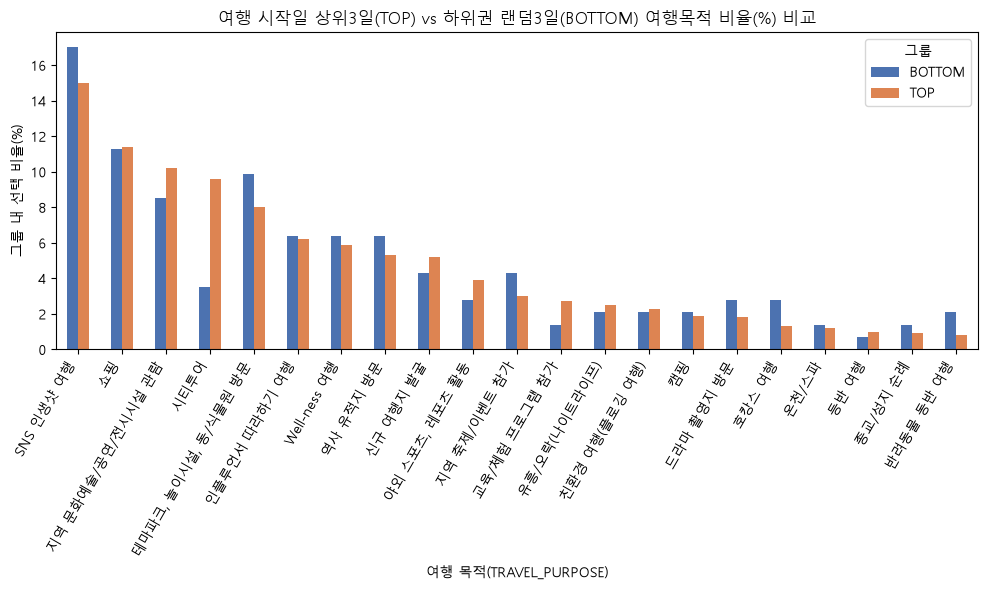

In [6]:
purpose_pivot.plot(kind="bar", figsize=(10, 6), color=["#4C72B0", "#DD8452"])
# TOP/BOTTOM 비율을 목적별로 나란히 비교하는 막대그래프

plt.title("여행 시작일 상위3일(TOP) vs 하위권 랜덤3일(BOTTOM) 여행목적 비율(%) 비교")
# 그래프 제목

plt.xlabel("여행 목적(TRAVEL_PURPOSE)")
# x축 이름

plt.ylabel("그룹 내 선택 비율(%)")
# y축 이름

plt.ylim(bottom=0)
# y축이 0부터 시작하도록 고정 (팀 데이터분석 원칙)

plt.xticks(rotation=60, ha="right")
# 목적 이름이 길어서 겹치지 않도록 x축 라벨을 60도 회전

plt.legend(title="그룹")
# 범례 제목을 "그룹"으로 지정

plt.tight_layout()
# 라벨이 잘리지 않도록 여백 자동 조정

plt.show()
# 그래프 표시

In [7]:
print("한계 (7원칙 6번: 결론마다 반대 해석 포함)")
# 아래 출력이 무엇인지 안내

print("- BOTTOM 3일은 cnt>=10인 71개 날짜 중 하위 25%(18개) 풀에서 시드(20260805) 고정 랜덤 추출한 것으로,")
print("  '진짜 최하위 3일'이 아니라 '표본이 너무 작지는 않은 날짜들 중 무작위로 고른 낮은 편'에 가까움")
# 하위권 정의가 엄밀한 최하위가 아니라 조건부 랜덤 추출이라는 한계

print("- TRAVEL_PURPOSE는 다중선택이라 그룹별 pct 합이 100%를 넘을 수 있음 (여행 1건이 여러 목적으로 중복 집계됨)")
# 다중선택 특성으로 인해 발생하는 해석상 유의사항

print("- TOP은 3일(다건), BOTTOM은 3일(소건)로 절대 표본 크기 차이가 커서,")
print("  여기서 나타난 비율 차이가 '날짜의 특성'인지 '표본 크기 차이로 인한 우연'인지는 이 결과만으로 단정할 수 없음")
# 인과관계를 단정하지 않고 대안 해석을 남겨두기 위한 코멘트

한계 (7원칙 6번: 결론마다 반대 해석 포함)
- BOTTOM 3일은 cnt>=10인 71개 날짜 중 하위 25%(18개) 풀에서 시드(20260805) 고정 랜덤 추출한 것으로,
  '진짜 최하위 3일'이 아니라 '표본이 너무 작지는 않은 날짜들 중 무작위로 고른 낮은 편'에 가까움
- TRAVEL_PURPOSE는 다중선택이라 그룹별 pct 합이 100%를 넘을 수 있음 (여행 1건이 여러 목적으로 중복 집계됨)
- TOP은 3일(다건), BOTTOM은 3일(소건)로 절대 표본 크기 차이가 커서,
  여기서 나타난 비율 차이가 '날짜의 특성'인지 '표본 크기 차이로 인한 우연'인지는 이 결과만으로 단정할 수 없음
